<a href="https://colab.research.google.com/github/manuelapop/health_classification_dataset_model_train/blob/main/dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

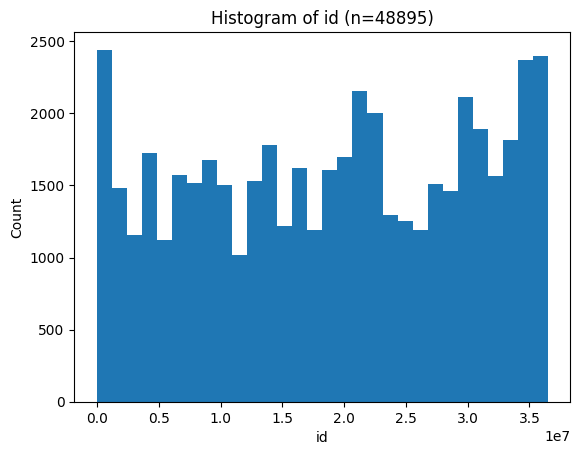

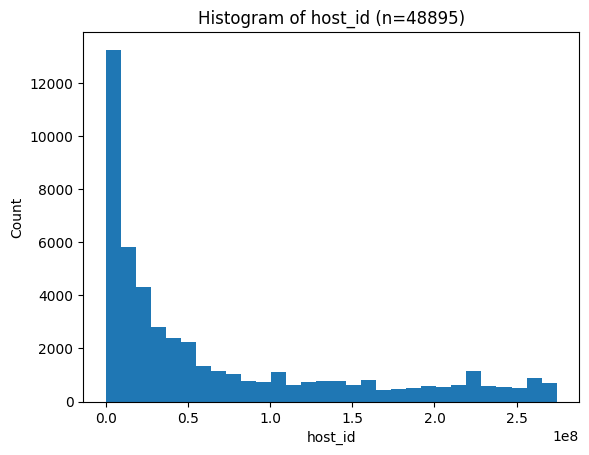

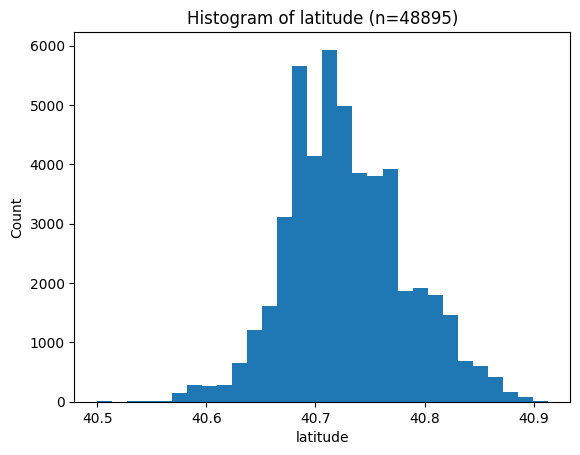

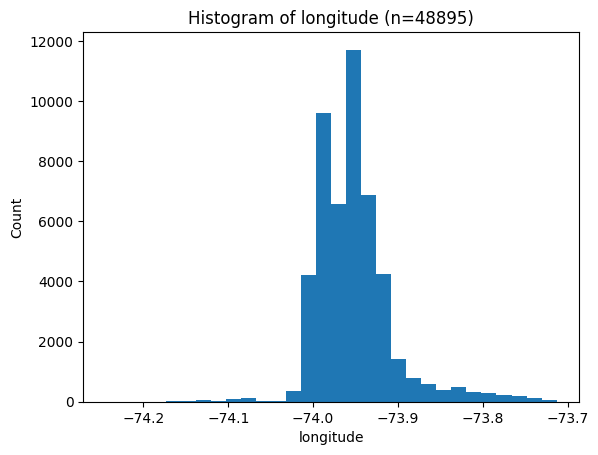

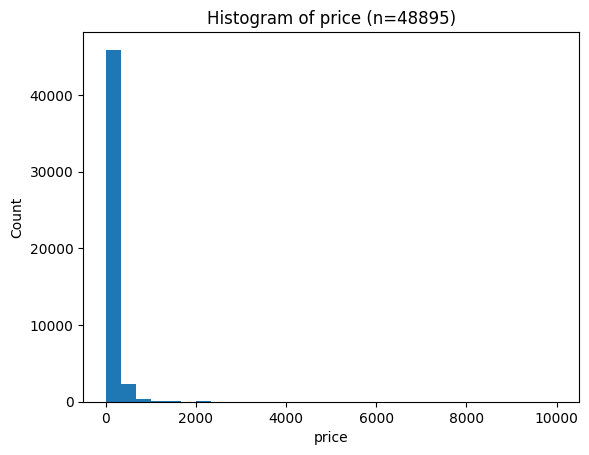

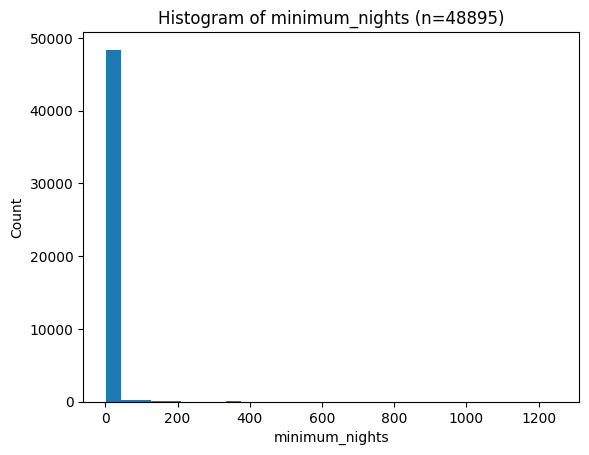

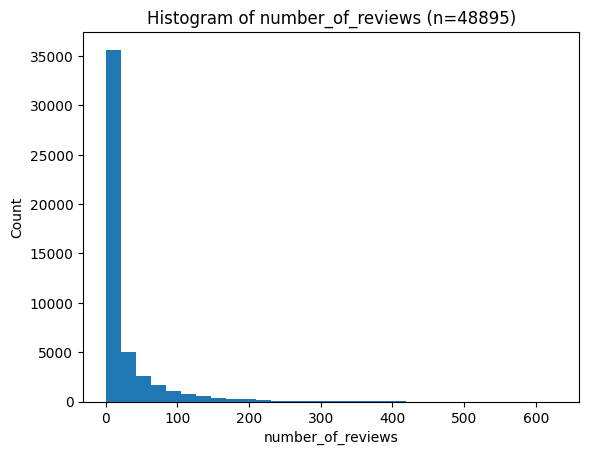

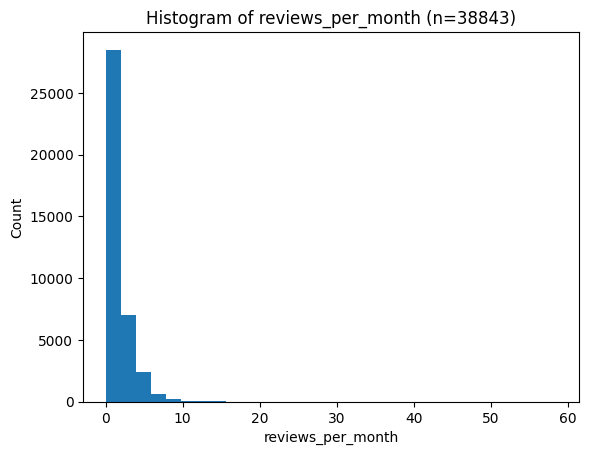

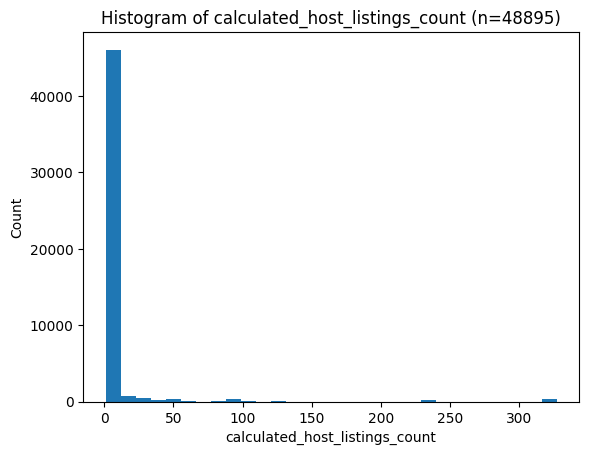

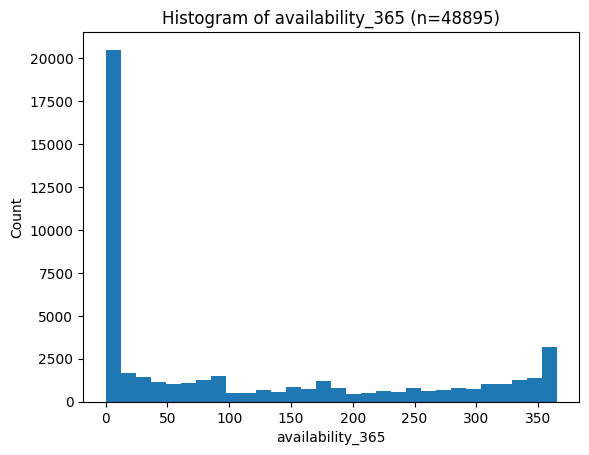

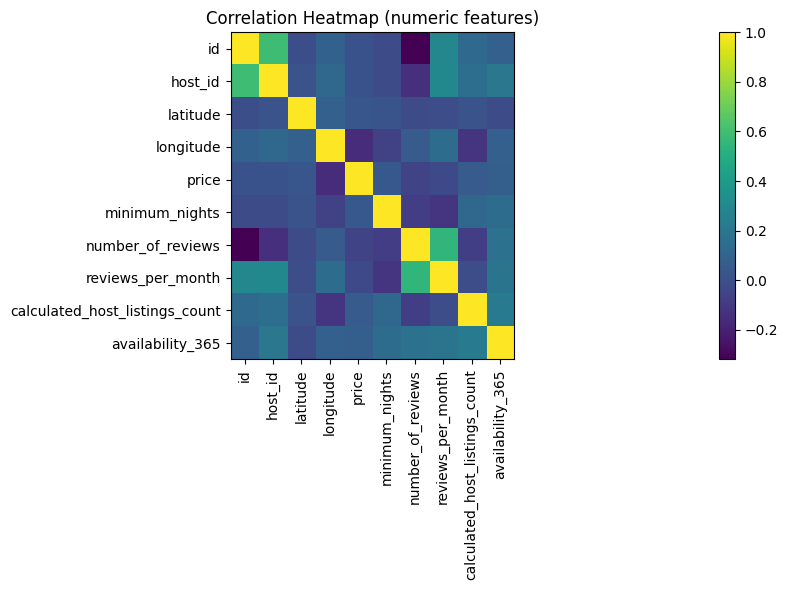

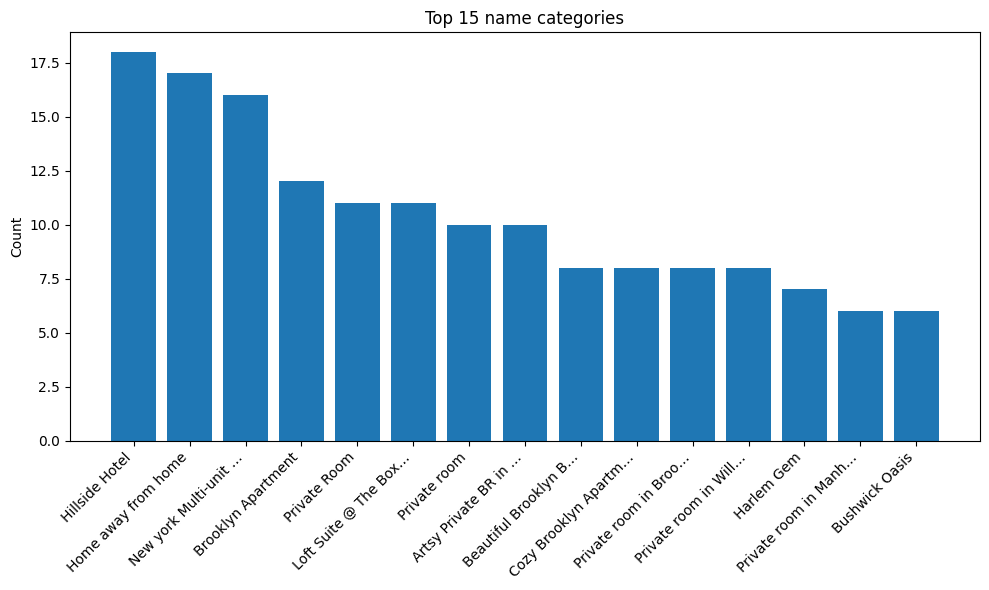

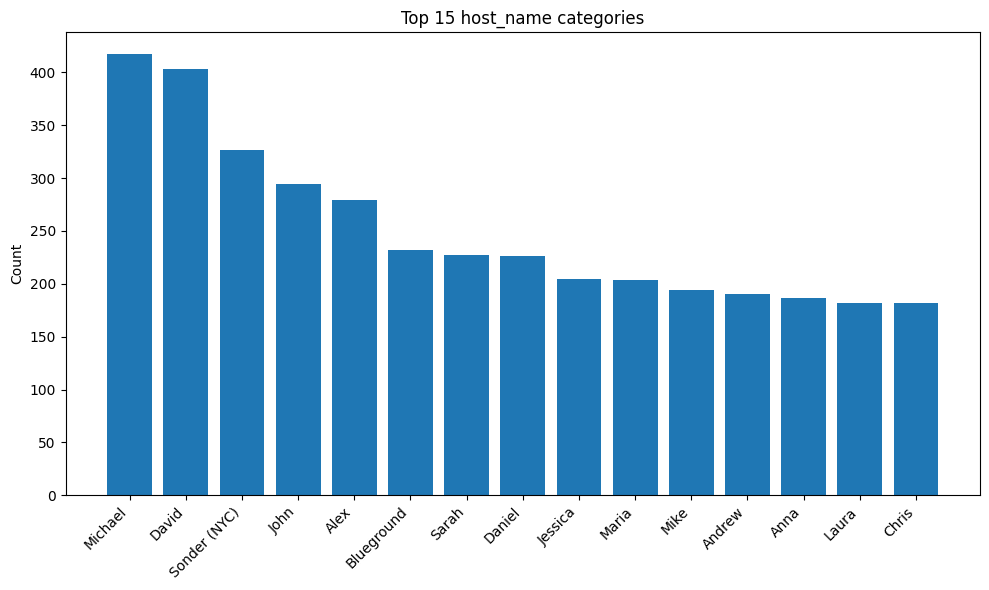

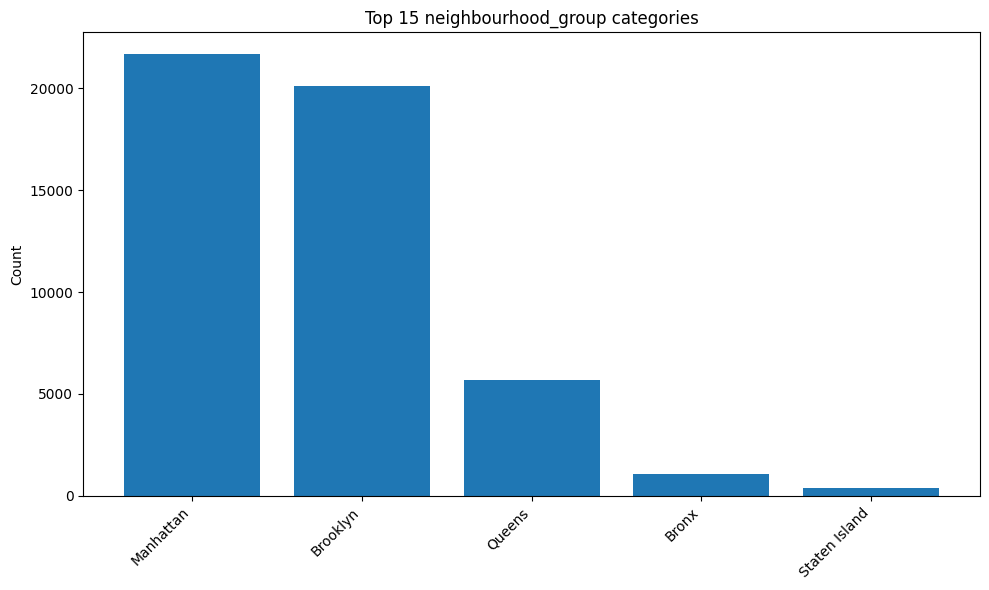

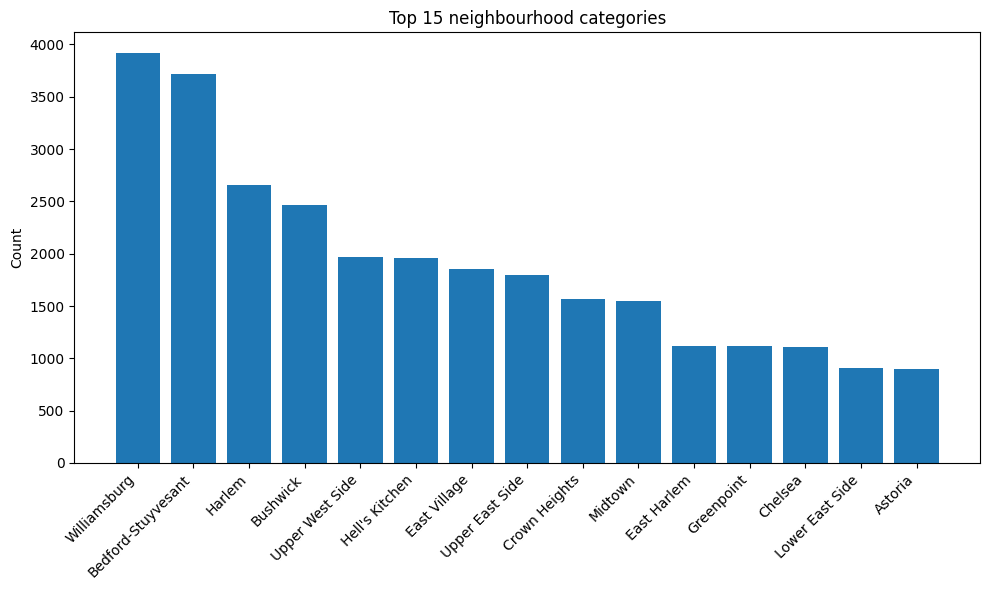

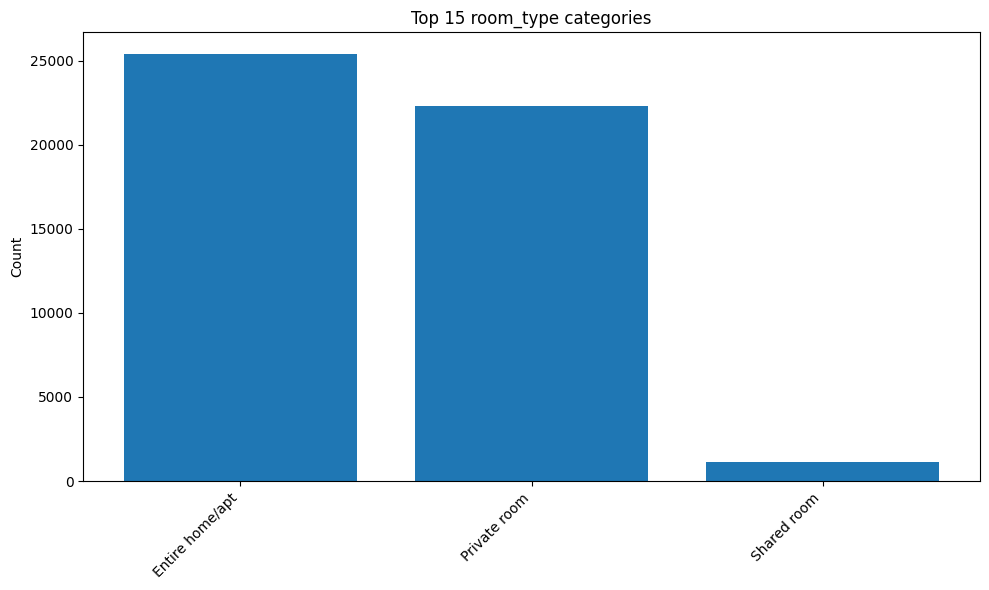

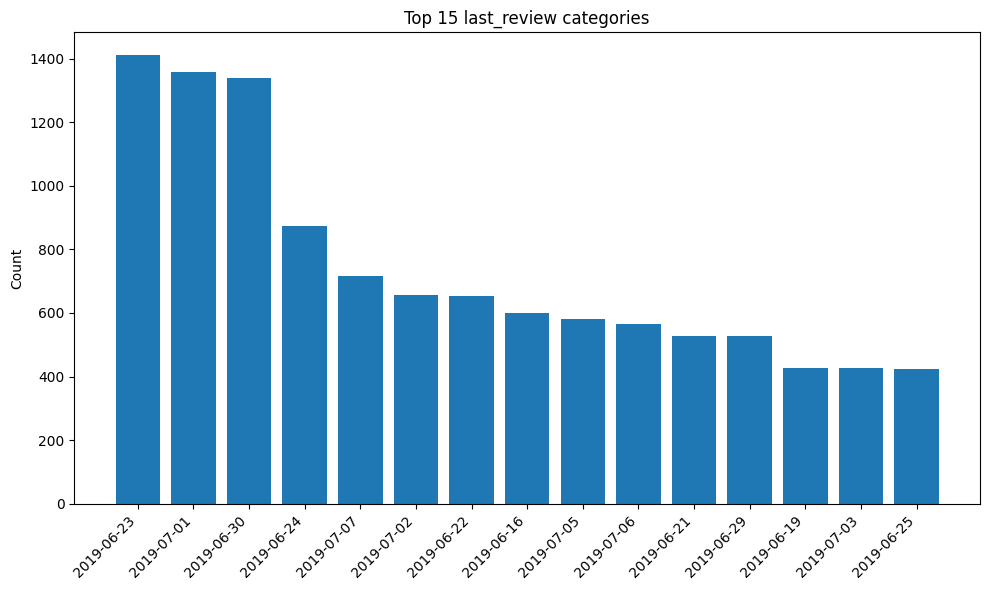

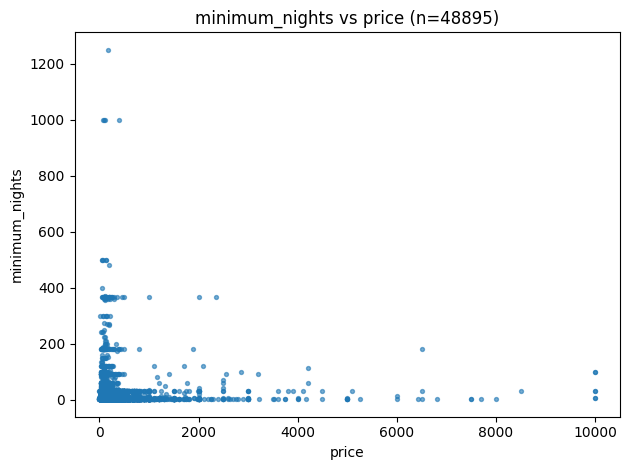

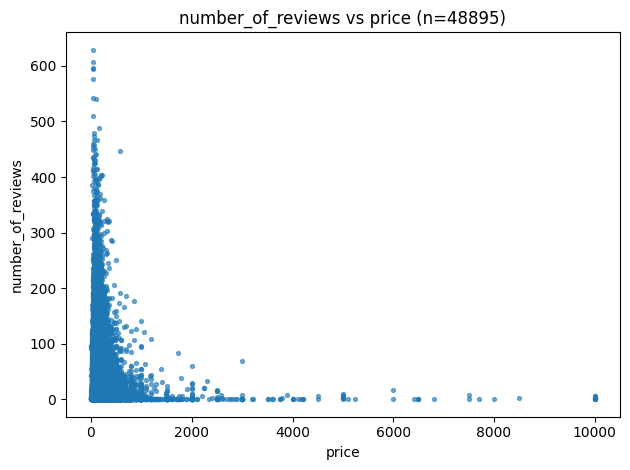

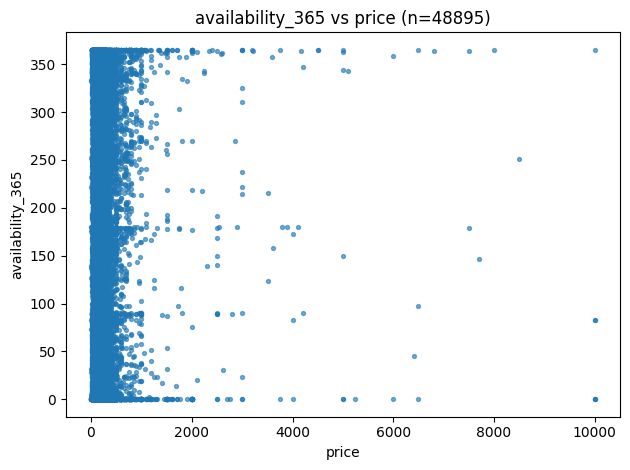

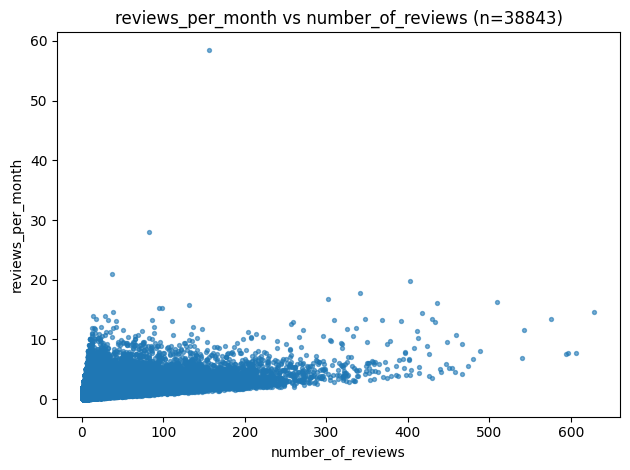

Saved plots to: /content/airbnb_plots


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "Quiz5_Air_BnB_in_NYC.csv"  # Change if your file is elsewhere
OUTPUT_DIR = "airbnb_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]
df.info()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

def safe_title(s: str, maxlen: int = 80) -> str:
    s = str(s)
    if len(s) <= maxlen:
        return s
    return s[:maxlen] + "…"

# Histograms
for col in numeric_cols:
    try:
        plt.figure()
        series = df[col].dropna()
        if series.empty:
            plt.close()
            continue
        plt.hist(series, bins=30)
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.title(safe_title(f"Histogram of {col} (n={len(series)})"))
        out = os.path.join(OUTPUT_DIR, f"hist_{col}.png")
        plt.show()
        plt.savefig(out, bbox_inches="tight", dpi=150)
        plt.close()
    except Exception as e:
        print(f"[warn] Could not plot histogram for {col}: {e}")

# Correlation heatmap (numeric only)
if len(numeric_cols) >= 2:
    try:
        corr = df[numeric_cols].corr(numeric_only=True)
        plt.figure(figsize=(8, 6))
        im = plt.imshow(corr.values, aspect="auto", interpolation="nearest")
        plt.colorbar(im, fraction=0.046, pad=0.4)
        plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
        plt.yticks(range(len(numeric_cols)), numeric_cols)
        plt.title("Correlation Heatmap (numeric features)")
        plt.tight_layout()
        out = os.path.join(OUTPUT_DIR, "correlation_heatmap.png")
        plt.show()
        plt.savefig(out, dpi=150)
        plt.close()
    except Exception as e:
        print(f"[warn] Could not plot correlation heatmap: {e}")

# Top-k categories for categoricals
TOP_K = 15
for col in categorical_cols:
    try:
        plt.figure(figsize=(10, 6))
        counts = df[col].astype("category").value_counts().head(TOP_K)
        if counts.empty:
            plt.close()
            continue
        plt.bar(range(len(counts)), counts.values)
        plt.xticks(range(len(counts)), [safe_title(str(x), maxlen=20) for x in counts.index], rotation=45, ha="right")
        plt.ylabel("Count")
        plt.title(safe_title(f"Top {TOP_K} {col} categories"))
        plt.tight_layout()
        out = os.path.join(OUTPUT_DIR, f"bar_top_{TOP_K}_{col}.png")
        plt.show()
        plt.savefig(out, dpi=150)
        plt.close()
    except Exception as e:
        print(f"[warn] Could not plot categorical counts for {col}: {e}")

# Helpful bivariate plots if columns exist
common_pairs = [
    ("price", "minimum_nights"),
    ("price", "number_of_reviews"),
    ("price", "availability_365"),
    ("number_of_reviews", "reviews_per_month"),
]
for x_col, y_col in common_pairs:
    if x_col in df.columns and y_col in df.columns:
        try:
            plt.figure()
            x = pd.to_numeric(df[x_col], errors="coerce")
            y = pd.to_numeric(df[y_col], errors="coerce")
            mask = x.notna() & y.notna()
            if mask.sum() == 0:
                plt.close()
                continue
            plt.scatter(x[mask], y[mask], s=8, alpha=0.6)
            plt.xlabel(x_col)
            plt.ylabel(y_col)
            plt.title(safe_title(f"{y_col} vs {x_col} (n={mask.sum()})"))
            out = os.path.join(OUTPUT_DIR, f"scatter_{y_col}_vs_{x_col}.png")
            plt.tight_layout()
            plt.show()
            plt.savefig(out, dpi=150)
            plt.close()
        except Exception as e:
            print(f"[warn] Could not plot scatter {y_col} vs {x_col}: {e}")

print(f"Saved plots to: {os.path.abspath(OUTPUT_DIR)}")